# **Library and Data import**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
import pickle
import warnings
warnings.filterwarnings('ignore')

In [ ]:
data = pd.read_csv('/content/online_retail_II.csv')
df = pd.DataFrame(data)
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


# **Exploratory Data Analysis**

**1.1 Overview**

In [ ]:
df.columns = [c.replace(' ', '') for c in df.columns]

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   CustomerID   824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [ ]:
#Total missing values
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,4382
Quantity,0
InvoiceDate,0
Price,0
CustomerID,243007
Country,0


There are significant missing values in two columns Description and CustomerID. Since these information affects product analysis and customer behaviour analysis directly, proper missing values handling is necessary. Possible solutions for handling missing values

*   Description column: Check the StockCode to map products, then fill the Description column with mapped products. Mark null products that can not be mapped as 'Unknown'.
*   Customer ID column: Dropping null values although the missing proportion is ~20% of the dataset. This is due to the ultimate goal of customer segmentation, unknown customers can be distorted



In [ ]:
#Total duplicates
total_duplicates = df.duplicated().sum()
print(f"Total number of duplicate rows: {total_duplicates}")

Total number of duplicate rows: 34335


In [ ]:
#Distribution of numeric attributes
df.describe()

,Quantity,Price,CustomerID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [ ]:
reference = (df.groupby('StockCode')['Description'].agg(lambda x: x.dropna().value_counts().idxmax() if x.dropna().shape[0] > 0 else 'Unknown'))
df['Description'] = df['Description'].fillna(df['StockCode'].map(reference))
df = df.dropna(subset=['CustomerID'])

In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['CustomerID'] = df['CustomerID'].astype(int)

From the five-number summary above of two numerical columns Quantity and Price, there are significant negative values in both columns. These negative values may derive from refund and return orders.

In [ ]:
df.sort_values(by=['Invoice', 'InvoiceDate'])
print(df[df['Quantity'] < 0][['Invoice', 'InvoiceDate', 'Quantity']])

         Invoice         InvoiceDate  Quantity
178      C489449 2009-12-01 10:33:00       -12
179      C489449 2009-12-01 10:33:00        -6
180      C489449 2009-12-01 10:33:00        -4
181      C489449 2009-12-01 10:33:00        -6
182      C489449 2009-12-01 10:33:00       -12
...          ...                 ...       ...
1065910  C581490 2011-12-09 09:57:00       -11
1067002  C581499 2011-12-09 10:28:00        -1
1067176  C581568 2011-12-09 11:57:00        -5
1067177  C581569 2011-12-09 11:58:00        -1
1067178  C581569 2011-12-09 11:58:00        -5

[18744 rows x 3 columns]


In [ ]:
negative_transactions_no_C = df[(df['Quantity'] < 0) & (~df['Invoice'].str.startswith('C'))]
print(negative_transactions_no_C['Invoice'].unique())
total_quantity = negative_transactions_no_C['Quantity'].count()
print(total_quantity)
print(negative_transactions_no_C)

[]
0
Empty DataFrame
Columns: [Invoice, StockCode, Description, Quantity, InvoiceDate, Price, CustomerID, Country]
Index: []


In [ ]:
negative_transactions = df[df['Quantity'] < 0]
print(negative_transactions['Invoice'].unique())
negative_transactions['Invoice'].str.startswith('C').sum()

['C489449' 'C489459' 'C489476' ... 'C581499' 'C581568' 'C581569']


np.int64(18744)

There are 18744 negative values, which accounts for around 2% of the dataset, in the Quantity column. These values mostly derive from returned transactions (indicated the invoices that start with letter 'C').  




In [ ]:
df.sort_values(by=['Invoice'])
print(df[df['Price'] < 0][['Invoice', 'InvoiceDate', 'Quantity', 'Price']])

Empty DataFrame
Columns: [Invoice, InvoiceDate, Quantity, Price]
Index: []


Meanwhile, there are only five negative values in the Price column and these are mostly coming from refund products. This can be seen in the invoices that start with letter 'A'.

Since the StockCode is supposed to be a 5-digit integral number, there are some stock codes that do not follow this rule. These may be non-sales items such as gifts, postages, etc.

In [36]:
non_standard = df[~df['StockCode'].str.strip().str.match(r'^\d{5}[a-zA-Z]*$', na=False)]

In [ ]:
desc_groupings = non_standard.groupby('StockCode').first()
for i in non_standard.StockCode.unique():
    print(f'{i}: {desc_groupings[desc_groupings.index == i].Description.iloc[0]}')

POST: POSTAGE
D: Discount
M: Manual
C2: CARRIAGE
BANK CHARGES:  Bank Charges
TEST001: This is a test product.
TEST002: This is a test product.
PADS: PADS TO MATCH ALL CUSHIONS
ADJUST: Adjustment by john on 26/01/2010 16
ADJUST2: Adjustment by Peter on Jun 25 2010 
SP1002: KID'S CHALKBOARD/EASEL
DOT: DOTCOM POSTAGE
CRUK: CRUK Commission


There are some stockcodes that do not represent specific products, rather they are gift vouchers, unknown products, etc. These unidentified stockcodes will be removed

**1.3 Top Selling Products**

In [ ]:
df['Revenue'] = df['Quantity'] * df['Price']
top_selling_products = df.groupby(['StockCode', 'Description'])['Revenue'].sum().sort_values(ascending=False).head(10)
top_selling_products

,,Revenue
StockCode,Description,
22423,REGENCY CAKESTAND 3 TIER,269736.70
85123A,WHITE HANGING HEART T-LIGHT HOLDER,242700.51
85099B,JUMBO BAG RED RETROSPOT,134845.16
84879,ASSORTED COLOUR BIRD ORNAMENT,126354.18
POST,POSTAGE,112249.10
47566,PARTY BUNTING,102686.23
22086,PAPER CHAIN KIT 50'S CHRISTMAS,78366.93
79321,CHILLI LIGHTS,72229.34
21137,BLACK RECORD COVER FRAME,67127.15


In [ ]:
df.describe()

,Quantity,InvoiceDate,Price,CustomerID,Revenue
count,824364.000000,824364,824364.000000,824364.000000,824364.000000
mean,12.414574,2011-01-01 22:29:28.042054144,3.676800,15324.638504,20.195317
min,-80995.000000,2009-12-01 07:45:00,0.000000,12346.000000,-168469.600000
25%,2.000000,2010-07-06 11:58:00,1.250000,13975.000000,4.250000
50%,5.000000,2010-12-03 14:26:00,1.950000,15255.000000,11.250000
75%,12.000000,2011-07-27 15:14:00,3.750000,16797.000000,19.500000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,168469.600000
std,188.976099,NaN,70.241388,1697.464450,308.685001


In [ ]:
#Calculate the metrics for profit margin
metrics = df.groupby('StockCode').agg({
    'Quantity': 'sum',
    'Revenue': 'sum',
    'Price': 'mean'
}).reset_index()

In [ ]:
#Identify popular products
popularity_threshold = metrics['Quantity'].quantile(0.8)
popular_products = metrics[metrics['Quantity'] >= popularity_threshold]

In [ ]:
#Calculate standard deviation for price to check price variability
price_variability = df.groupby('StockCode')['Price'].std().reset_index()
price_variability.columns = ['StockCode', 'PriceStdDev']
popular_products = popular_products.merge(price_variability, on='StockCode', how='left')

In [ ]:
popular_products

,StockCode,Quantity,Revenue,Price,PriceStdDev
0,10002,7401,5877.97,0.839969,0.034744
1,10133,3331,1930.76,0.659299,0.212837
2,10135,3909,4075.64,1.222731,0.353057
3,11001,3513,5601.61,1.718762,0.322714
4,15034,8480,1055.46,0.136957,0.014314
...,...,...,...,...,...
925,85227,3185,2640.23,0.860708,0.097704
926,85230F,2968,732.08,0.277097,0.029664
927,85232B,2631,12546.05,4.910870,0.160978
928,M,4499,-185153.23,427.243202,1818.640981


In [ ]:
#Setting threshold for price variability
low_margin_threshold = metrics['Price'].quantile(0.75)
low_margin_products = popular_products[popular_products['PriceStdDev'] >= low_margin_threshold]
#Popular but low profit margins products
low_margin_products

,StockCode,Quantity,Revenue,Price,PriceStdDev
32,17003,70390,14612.35,0.687340,4.917128
489,22502,3043,54589.65,7.364508,36.868751
928,M,4499,-185153.23,427.243202,1818.640981
929,POST,5078,112249.10,33.542090,259.279826


**1.4 Sales Trends**

In [ ]:
# Extract Year, Month, and Day from InvoiceDate
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['Week'] = df['InvoiceDate'].dt.isocalendar().week

In [ ]:
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,Revenue,Year,Month,Day,Week
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.40,2009,12,1,49
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,2009,12,1,49
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,2009,12,1,49
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.80,2009,12,1,49
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.00,2009,12,1,49
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,12.60,2011,12,9,49
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,16.60,2011,12,9,49
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,16.60,2011,12,9,49
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680,France,14.85,2011,12,9,49


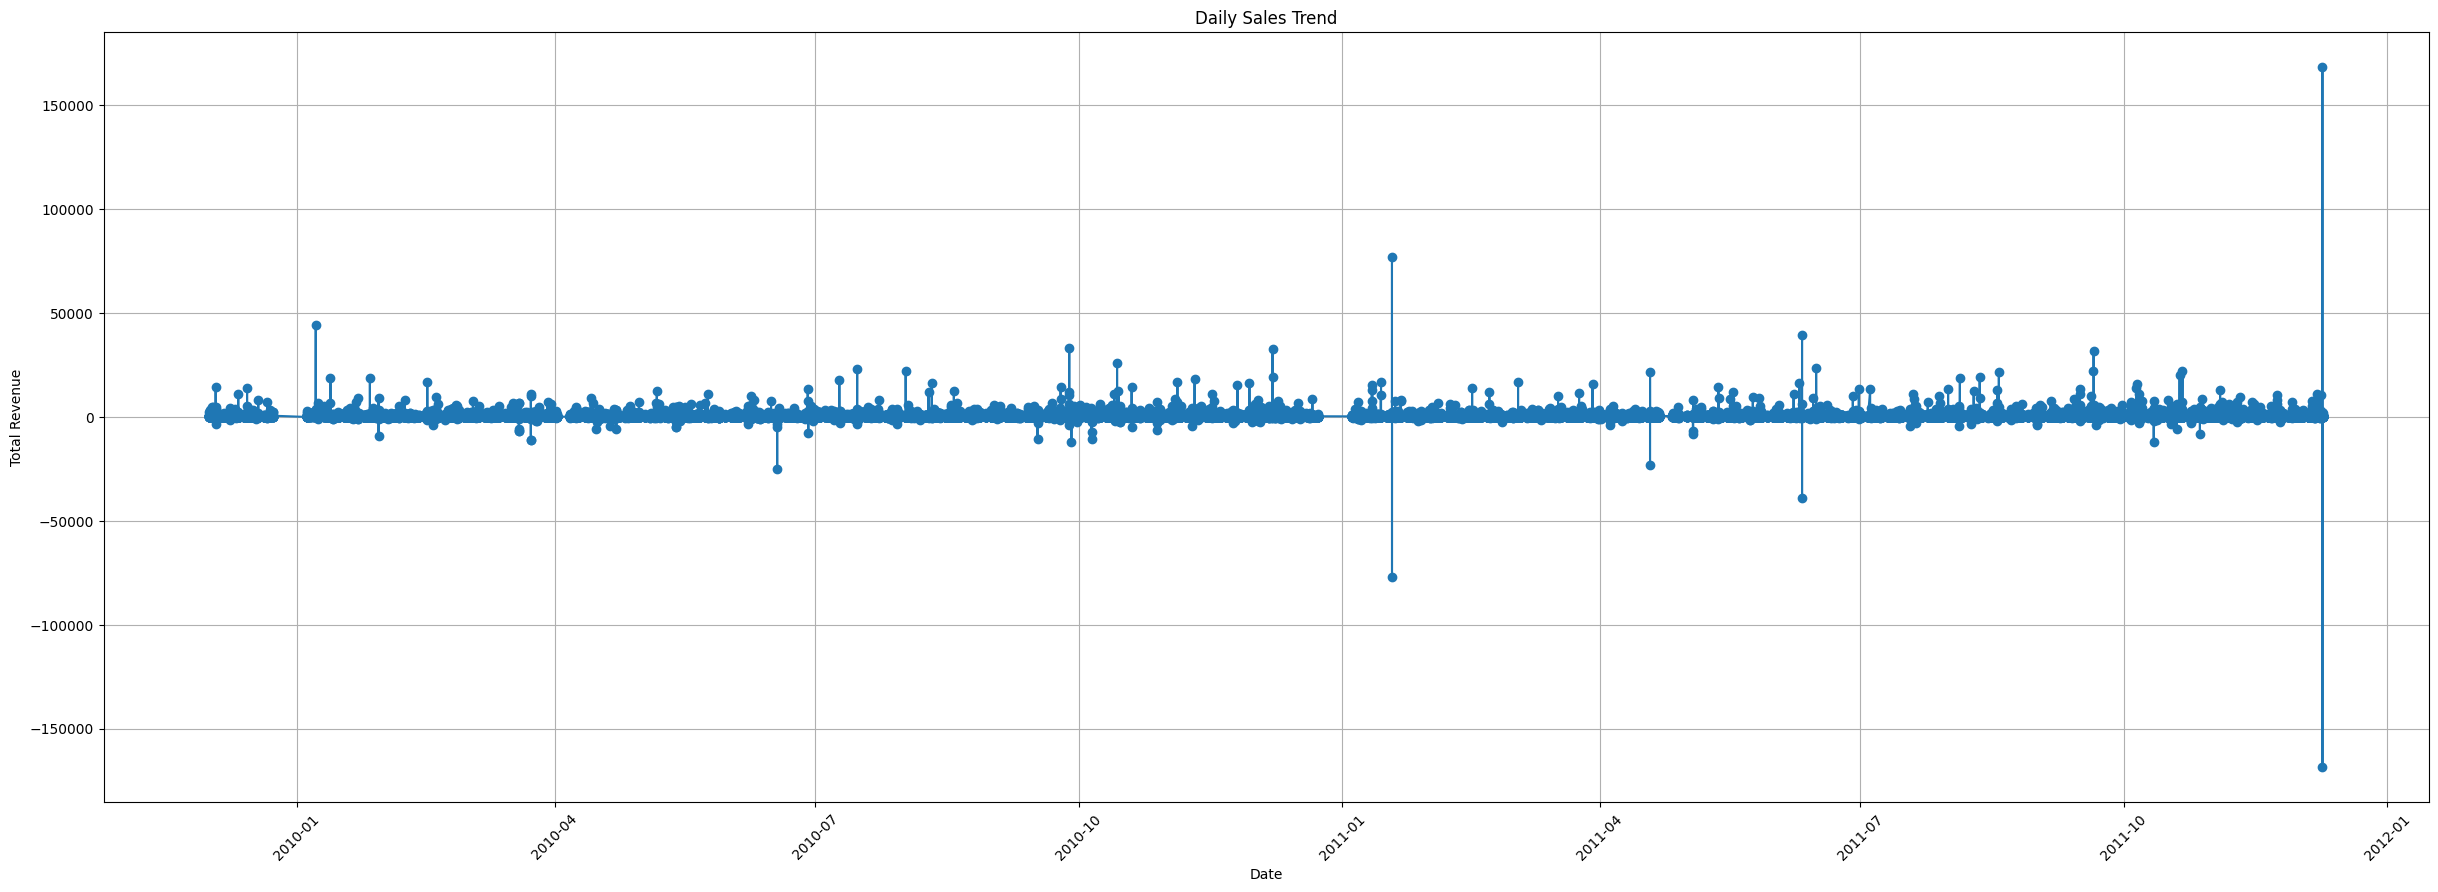

In [ ]:
daily_sales = df.groupby('InvoiceDate')['Revenue'].sum().reset_index()

# Plot daily sales trend
plt.figure(figsize=(30, 10))
plt.plot(daily_sales['InvoiceDate'], daily_sales['Revenue'], marker='o')
plt.title('Daily Sales Trend')
plt.xlabel('Date')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

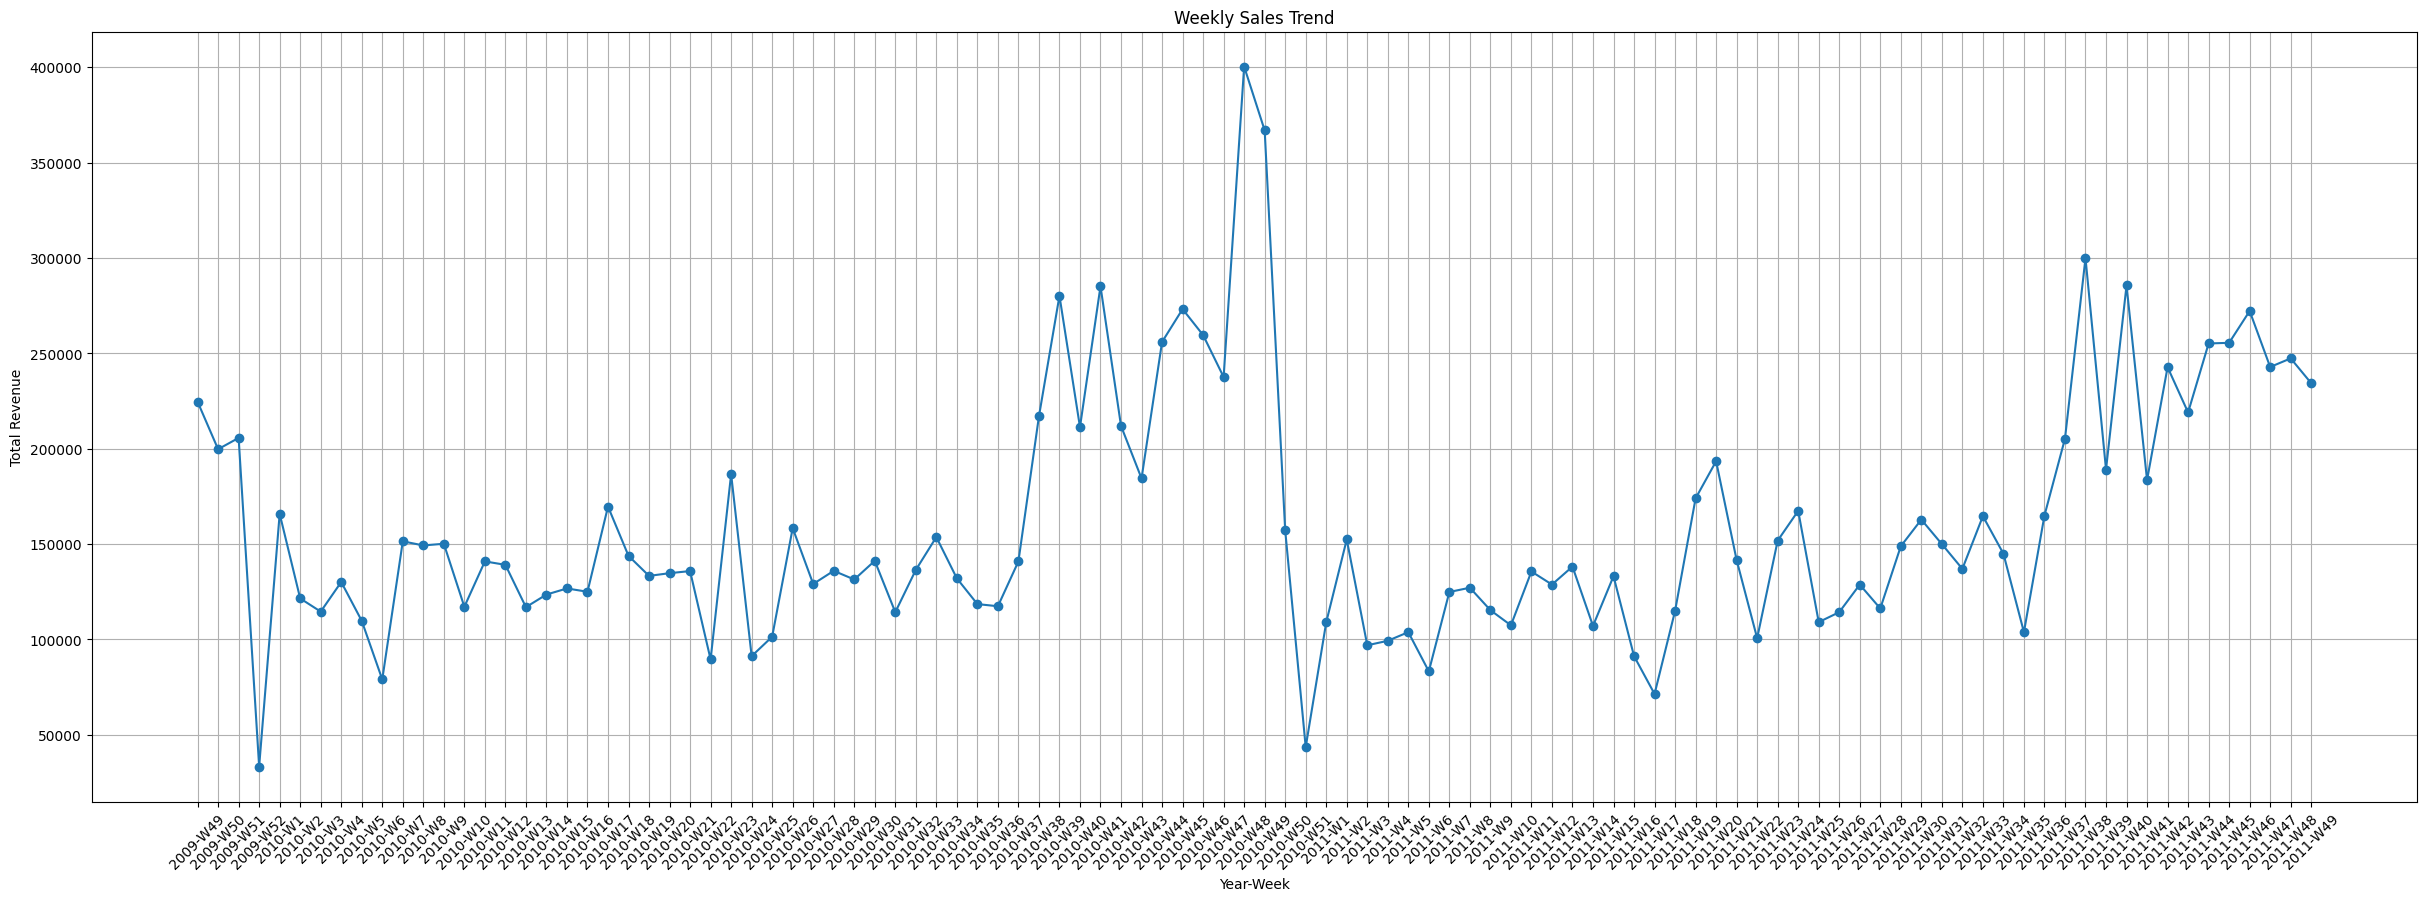

In [ ]:
weekly_sales = df.groupby(['Year', 'Week'])['Revenue'].sum().reset_index()
weekly_sales['YearWeek'] = weekly_sales['Year'].astype(str) + '-W' + weekly_sales['Week'].astype(str)

# Plot weekly sales trend
plt.figure(figsize=(30, 10))
plt.plot(weekly_sales['YearWeek'], weekly_sales['Revenue'], marker='o')
plt.title('Weekly Sales Trend')
plt.xlabel('Year-Week')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

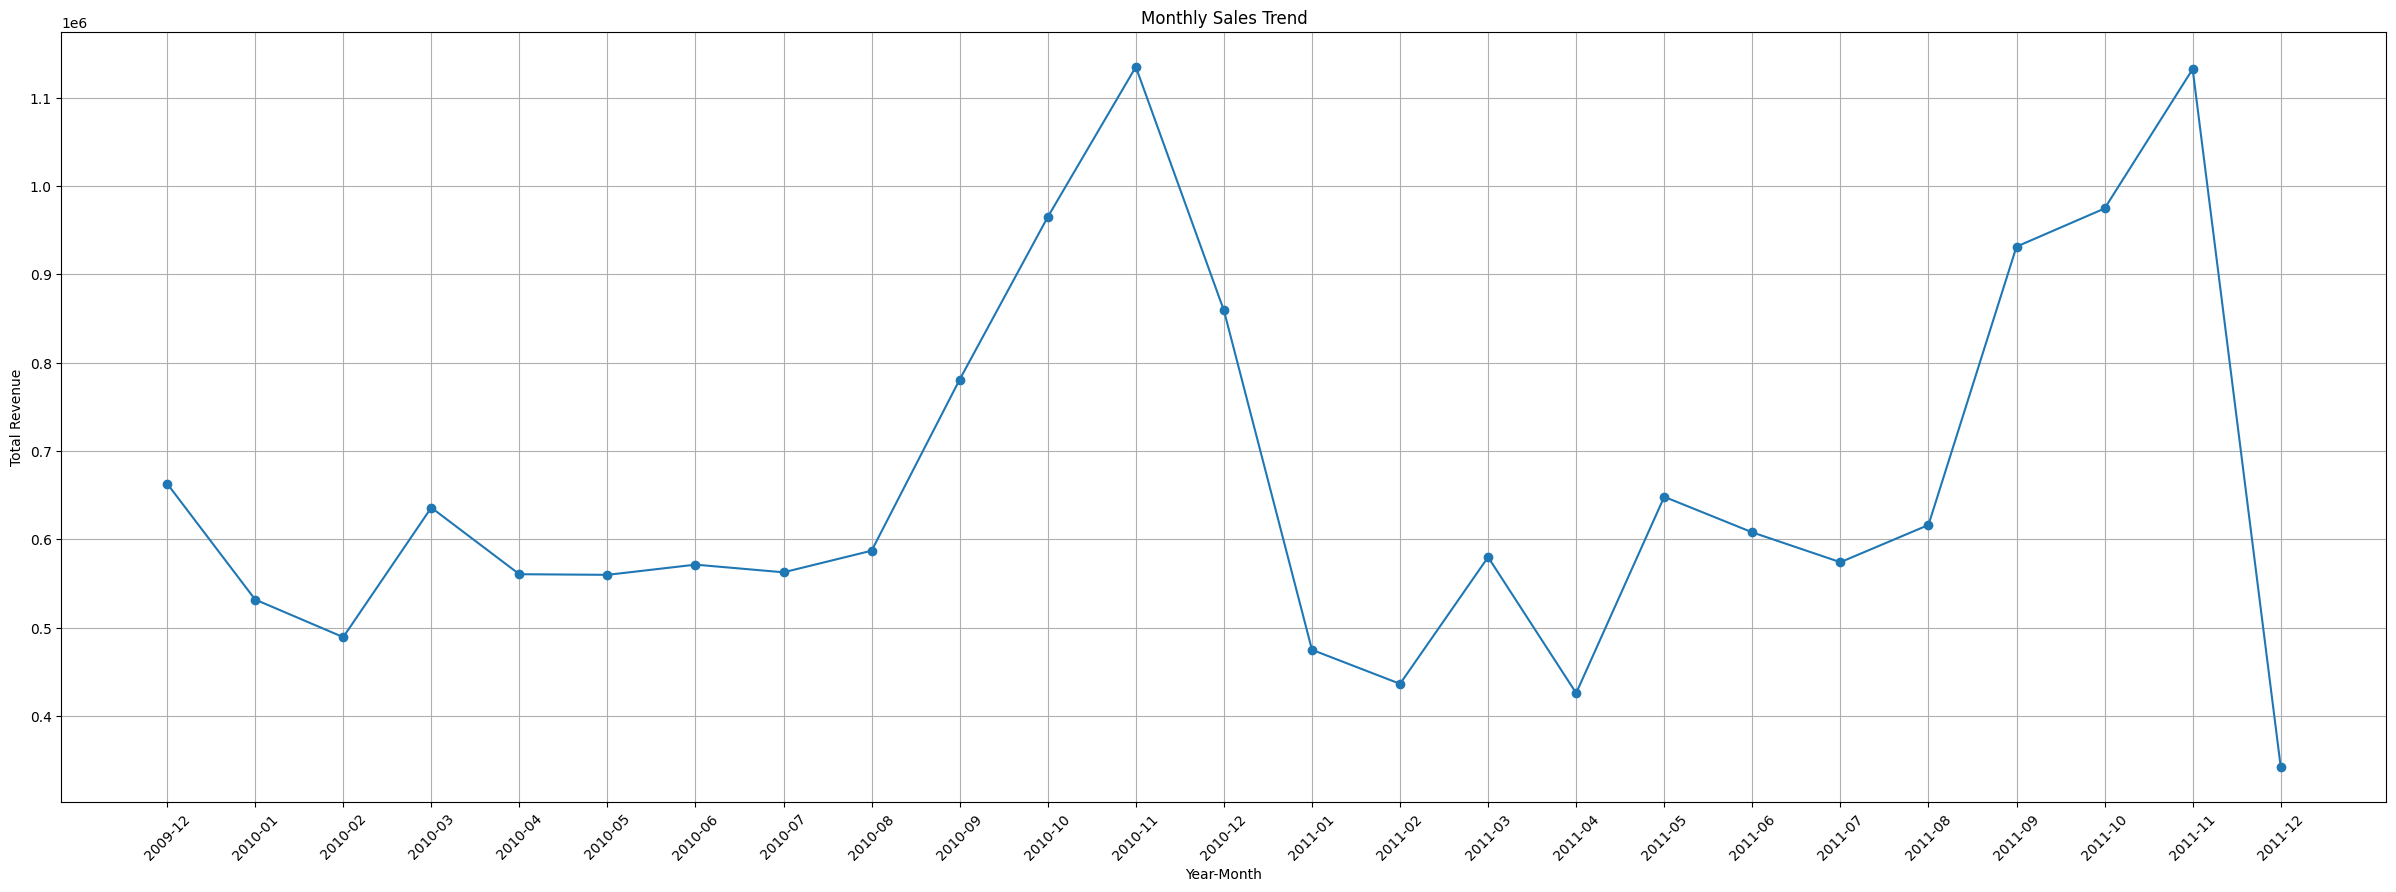

In [ ]:
# Plot monthly sales trends
monthly_sales = df.groupby(['Year', 'Month'])['Revenue'].sum().reset_index()
monthly_sales['YearMonth'] = monthly_sales['Year'].astype(str) + '-' + monthly_sales['Month'].astype(str).str.zfill(2)
plt.figure(figsize=(30, 10))
plt.plot(monthly_sales['YearMonth'], monthly_sales['Revenue'], marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Year-Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()
